In [14]:
print('Radha!')

Radha!


In [15]:
import operator
import os
from typing import Annotated, TypedDict

from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.constants import Send
from langgraph.graph import END, START, StateGraph
from dotenv import  load_dotenv

C:\Users\Deepak Kumar\AppData\Local\Temp\ipykernel_11980\2532387632.py:7: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [16]:
# ==========================================
# 1. STATE DEFINITIONS
# ==========================================

class ResearchState(TypedDict):
    """Global state shared across the main workflow graph."""

    topic: str
    tasks: list[str]
    results: Annotated[
        list[str], operator.add
    ]  # Appends outputs from workers automatically
    final_report: str


class WorkerState(TypedDict):
    """Input state passed into individual worker tasks via Send."""

    task: str

In [17]:
# ==========================================
# 2. LLM INITIALIZATION
# ==========================================

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [18]:
# ==========================================
# 3. NODE DEFINITIONS
# ==========================================

In [19]:
## Orchestrator Node

def orchestrator(state: ResearchState):
    """Breaks down the main research topic into distinct sub-tasks."""
    prompt = f"""
    You are an expert research planner. 
    Break down the following research topic into 3 distinct, actionable sub-tasks:
    Topic: {state['topic']}
    
    Return ONLY 3 lines, each containing one sub-task without numbering.
    """
    response = llm.invoke([HumanMessage(content=prompt)])

    # Split response line-by-line into clean tasks
    tasks = [
        task.strip()
        for task in response.content.strip().split("\n")
        if task.strip()
    ]

    print(f"\n📋 [Orchestrator] Created {len(tasks)} sub-tasks:")
    for t in tasks:
        print(f"   - {t}")

    return {"tasks": tasks}


In [20]:
## Worker Node

def worker(state: WorkerState):
    """Executes an individual research sub-task independently."""
    task = state["task"]
    print(f"⚙️ [Worker] Processing task: {task}")

    prompt = f"Provide a concise 2-sentence research summary for this task: {task}"
    response = llm.invoke([HumanMessage(content=prompt)])

    # Returning a list here appends to ResearchState['results'] thanks to operator.add
    return {"results": [f"### Task: {task}\n{response.content}\n"]}

In [21]:
## Report Aggregator Node

def generate_final_report(state: ResearchState):
    """Aggregates all worker results into a final structured document."""
    print("\n📝 [Synthesizer] Compiling final report...")

    all_findings = "\n".join(state["results"])

    prompt = f"""
    You are a technical document synthesizer. 
    Combine the following research findings for the topic '{state['topic']}' into a well-structured final report:
    
    Findings:
    {all_findings}
    """
    response = llm.invoke([HumanMessage(content=prompt)])

    return {"final_report": response.content}

In [22]:
# ==========================================
# 4. DYNAMIC ROUTING (FAN-OUT)
# ==========================================

def assign_workers(state: ResearchState):
    """Dynamically maps each task in state['tasks'] to a parallel worker node."""
    return [Send("worker", {"task": task}) for task in state["tasks"]]


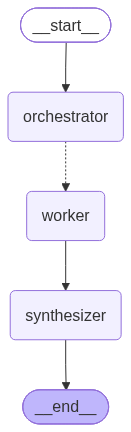

In [23]:
# ==========================================
# 5. GRAPH CONSTRUCTION & COMPILATION
# ==========================================

# 1. Initialize StateGraph
builder = StateGraph(ResearchState)

# 2. Add Nodes
builder.add_node("orchestrator", orchestrator)
builder.add_node("worker", worker)
builder.add_node("synthesizer", generate_final_report)

# 3. Define Flow & Edges
builder.add_edge(START, "orchestrator")

# Dynamic Fan-Out: Map 'orchestrator' output tasks into parallel 'worker' nodes
builder.add_conditional_edges("orchestrator", assign_workers, ["worker"])

# Fan-In: Fan back into 'synthesizer' once all workers complete, then finish
builder.add_edge("worker", "synthesizer")
builder.add_edge("synthesizer", END)

# 4. Compile the Graph
graph = builder.compile()
graph


In [24]:
# ==========================================
# 6. EXECUTION
# ==========================================

input_topic = {
        "topic": "Generative AI covering LLMs, RAG, and AI Agents"
    }

output = graph.invoke(input_topic)

print("\n" + "=" * 60)
print("FINAL GENERATED REPORT:")
print("=" * 60)
print(output["final_report"])


📋 [Orchestrator] Created 3 sub-tasks:
   - Conduct a literature review on the current advancements and applications of Large Language Models (LLMs) in various industries.
   - Investigate the integration and effectiveness of Retrieval-Augmented Generation (RAG) techniques in enhancing LLM performance.
   - Analyze the role and impact of AI agents in automating tasks and decision-making processes across different sectors.
⚙️ [Worker] Processing task: Conduct a literature review on the current advancements and applications of Large Language Models (LLMs) in various industries.
⚙️ [Worker] Processing task: Investigate the integration and effectiveness of Retrieval-Augmented Generation (RAG) techniques in enhancing LLM performance.
⚙️ [Worker] Processing task: Analyze the role and impact of AI agents in automating tasks and decision-making processes across different sectors.

📝 [Synthesizer] Compiling final report...

FINAL GENERATED REPORT:
# Final Report: Advancements and Applications o